# 公式 o2 — Lotka-Volterra（捕食者-被食者）

> **出典（E-Cell4 公式）**: Examples → *Lotka-Volterra 2D* — https://ecell4.e-cell.org/examples/example07.html
>
> E-Cell4 公式例題の移植。公式コードをそのまま使う（プロットのみ matplotlib で描画）。

**この例が教えること**: (A) **速度式（rate-law）を関数で書く** ODE モデル、(B) 同じ系を**素反応**に分解して
**Gillespie（確率）**で回す書き方、(C) さらに空間（`meso`）へ拡張できること。

## A) 速度式 ODE（公式そのまま）

`~u > u | 速度式` は「u が生成/消滅する反応の速度を、任意の式で与える」記法。連立 ODE
$\dot u = u(1-v),\ \dot v = \alpha v(u-1)$ を直接書いている。

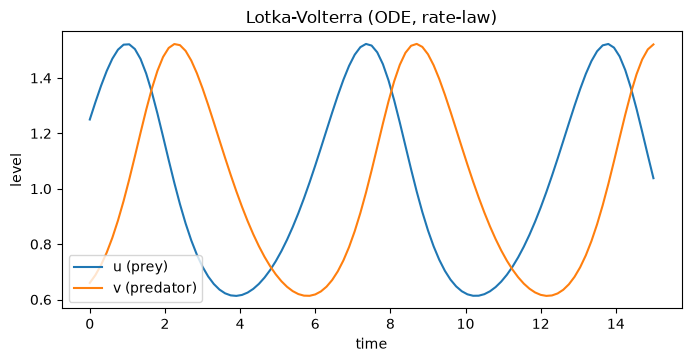

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, matplotlib.pyplot as plt
from ecell4.prelude import *

alpha = 1
with reaction_rules():
    ~u > u | u * (1 - v)
    ~v > v | alpha * v * (u - 1)
m = get_model()
ret = run_simulation(15, {'u': 1.25, 'v': 0.66}, model=m, species_list=['u','v'])
a = ret.as_array()
plt.figure(figsize=(8,3.6))
plt.plot(a[:,0], a[:,1], label='u (prey)'); plt.plot(a[:,0], a[:,2], label='v (predator)')
plt.xlabel('time'); plt.ylabel('level'); plt.legend(); plt.title('Lotka-Volterra (ODE, rate-law)'); plt.show()

## B) 素反応 + Gillespie（公式そのまま）

同じ生態を**質量作用の素反応**に分解: 被食者増殖 `u>u+u`、捕食 `u+v>v`、捕食による増殖 `u+v>u+v+v`、捕食者死 `v>~v`。
分子数スケール（×1600）にして ODE と Gillespie を比べる。

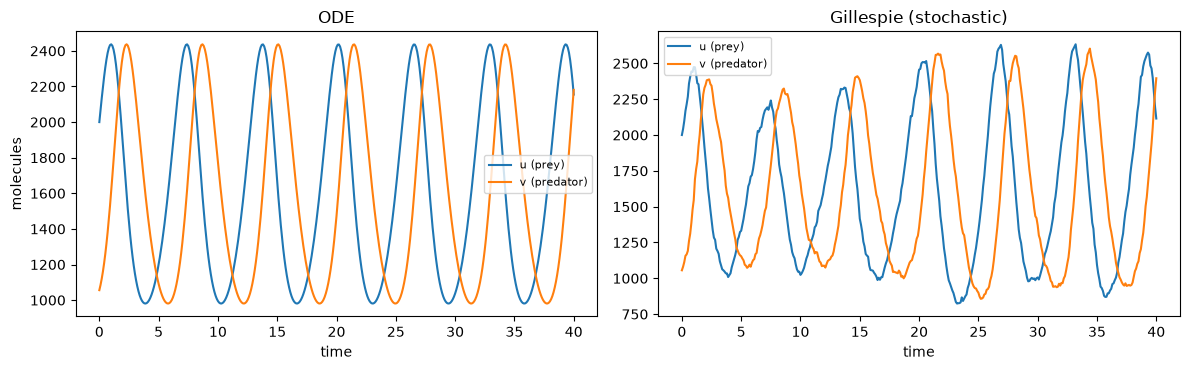

In [2]:
alpha = 1
with species_attributes():
    u | v | {'D': 0.1}
with reaction_rules():
    u > u + u | 1.0
    u + v > v | 1.0
    u + v > u + v + v | alpha
    v > ~v | alpha
m = get_model()
session = Session(model=m, y0={'u': 1.25*1600, 'v': 0.66*1600}, volume=1600)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, solver, title in [(ax1, 'ode', 'ODE'), (ax2, 'gillespie', 'Gillespie (stochastic)')]:
    d = session.run(40, ndiv=400, solver=solver).as_df()
    ax.plot(d['t'], d['u'], label='u (prey)'); ax.plot(d['t'], d['v'], label='v (predator)')
    ax.set_xlabel('time'); ax.set_title(title); ax.legend(fontsize=8)
ax1.set_ylabel('molecules'); plt.tight_layout(); plt.show()

## 読み取り

- **ODE** は理想的な周期振動（捕食者と被食者が位相をずらして増減）。
- **Gillespie** は同じ平均挙動だが、有限分子数ゆえ振幅・位相が確率的に揺らぐ（少数だと絶滅もありうる）。
- 公式例題ではさらに **`solver=('meso', Integer3(160,160,1))`** と `volume=Real3(40,40,1)` にするだけで
  **2 次元空間の反応拡散**（パッチ状のパターン形成）へ拡張できる（本ノートでは省略。出典ページ参照）。

**要点（公式が教えたい機能）**: 同じモデルを **rate-law ODE / 素反応 Gillespie / 空間 meso** と、書き方をほぼ変えず横断できる。